In [1]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", path)

META_PATH = os.path.join(path, "HAM10000_metadata.csv")
IMG_DIRS = [
    os.path.join(path, "HAM10000_images_part_1"),
    os.path.join(path, "HAM10000_images_part_2"),
]

df = pd.read_csv(META_PATH)
print("Rows loaded:", len(df))
df.head()

Dataset path: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2
Rows loaded: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
LABEL_MAP = {
    "akiec": "Actinic Keratoses / Intraepithelial Carcinoma",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevi",
    "vasc": "Vascular Lesions",
}

MALIGNANT = {"mel", "bcc", "akiec"}

image_paths = {}
for d in IMG_DIRS:
    for fp in glob.glob(os.path.join(d, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(fp))[0]
        image_paths[image_id] = fp

df["image_path"] = df["image_id"].map(image_paths)
df["dx_full"] = df["dx"].map(LABEL_MAP)
df["malignant"] = df["dx"].isin(MALIGNANT)

print("Missing image paths:", df["image_path"].isna().sum())
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Final rows:", len(df))
print(df["dx"].value_counts())

Missing image paths: 0
Final rows: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [5]:
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_index = {cls: i for i, cls in enumerate(CLASS_NAMES)}
index_to_class = {i: cls for cls, i in class_to_index.items()}

df = df[df["dx"].isin(CLASS_NAMES)].copy()
df["label"] = df["dx"].map(class_to_index)

print("Class mapping:", class_to_index)
df[["dx", "label"]].head()

Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain distribution:")
print(train_df["dx"].value_counts())

print("\nValidation distribution:")
print(val_df["dx"].value_counts())

print("\nTest distribution:")
print(test_df["dx"].value_counts())

Train size: 7010
Val size: 1502
Test size: 1503

Train distribution:
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Validation distribution:
dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       21
df         17
Name: count, dtype: int64

Test distribution:
dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       22
df         17
Name: count, dtype: int64


In [7]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = len(CLASS_NAMES)
AUTOTUNE = tf.data.AUTOTUNE

In [8]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)  # ResNet50 preprocessing
    return image, tf.one_hot(label, depth=NUM_CLASSES)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.30),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.50),
], name="data_augmentation")

LIMIT_PER_CLASS = 500

def build_balanced_dataset(dataframe, training=False):
    if not training:
        paths = dataframe["image_path"].values
        labels = dataframe["label"].values
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
        return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE), ()

    # we need to balance training dataset
    class_counts = dataframe["label"].value_counts()
    majority_count = LIMIT_PER_CLASS

    original_dfs = []
    synthetic_dfs = []

    for class_label, count in class_counts.items():
        class_df = dataframe[dataframe["label"] == class_label]

        if count > LIMIT_PER_CLASS:
            class_df = class_df.sample(LIMIT_PER_CLASS, random_state=SEED)
            count = LIMIT_PER_CLASS

        original_dfs.append(class_df)

        if count < majority_count:
            remainder = majority_count - count
            synthetic = class_df.sample(remainder, replace=True, random_state=SEED)
            synthetic_dfs.append(synthetic)

    original_df = pd.concat(original_dfs)
    
    # original images
    orig_ds = tf.data.Dataset.from_tensor_slices(
        (original_df["image_path"].values, original_df["label"].values)
    )
    orig_ds = orig_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)

    synthetic_df = pd.concat(synthetic_dfs)

    # agumented dataset
    synth_ds = tf.data.Dataset.from_tensor_slices(
        (synthetic_df["image_path"].values, synthetic_df["label"].values)
    )
    synth_ds = synth_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    synth_ds = synth_ds.map(
        lambda x, y: (data_augmentation(x, training=True), y),
        num_parallel_calls=AUTOTUNE
    )

    # Combine and shuffle
    balanced_ds = orig_ds.concatenate(synth_ds)
    balanced_ds = balanced_ds.shuffle(buffer_size=len(original_df) + len(synthetic_df), seed=SEED)

    balanced_df = pd.concat([original_df, synthetic_df])
    print("Class distribution after balancing:")
    print(balanced_df["label"].value_counts())

    return balanced_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE), synthetic_df

train_ds, train_synthetic_df = build_balanced_dataset(train_df, training=True)
val_ds, _ = build_balanced_dataset(val_df, training=False)
test_ds, _ = build_balanced_dataset(test_df, training=False)

Class distribution after balancing:
label
5    500
4    500
2    500
1    500
0    500
6    500
3    500
Name: count, dtype: int64


In [23]:
classes = sorted(test_df["label"].unique())
for i, class_label in enumerate(classes):
    row = test_df[test_df["label"] == class_label].sample(1, random_state=SEED).iloc[0]
    print(f"Class: {index_to_class[class_label]}, Sample Image: {row['image_path']}")

Class: akiec, Sample Image: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_images_part_1\ISIC_0027802.jpg
Class: bcc, Sample Image: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_images_part_1\ISIC_0024573.jpg
Class: bkl, Sample Image: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_images_part_1\ISIC_0025038.jpg
Class: df, Sample Image: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_images_part_2\ISIC_0032468.jpg
Class: mel, Sample Image: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_images_part_1\ISIC_0029000.jpg
Class: nv, Sample Image: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_images_part_2\ISIC_0029972.jpg
Class: vasc, Sample Image: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-m

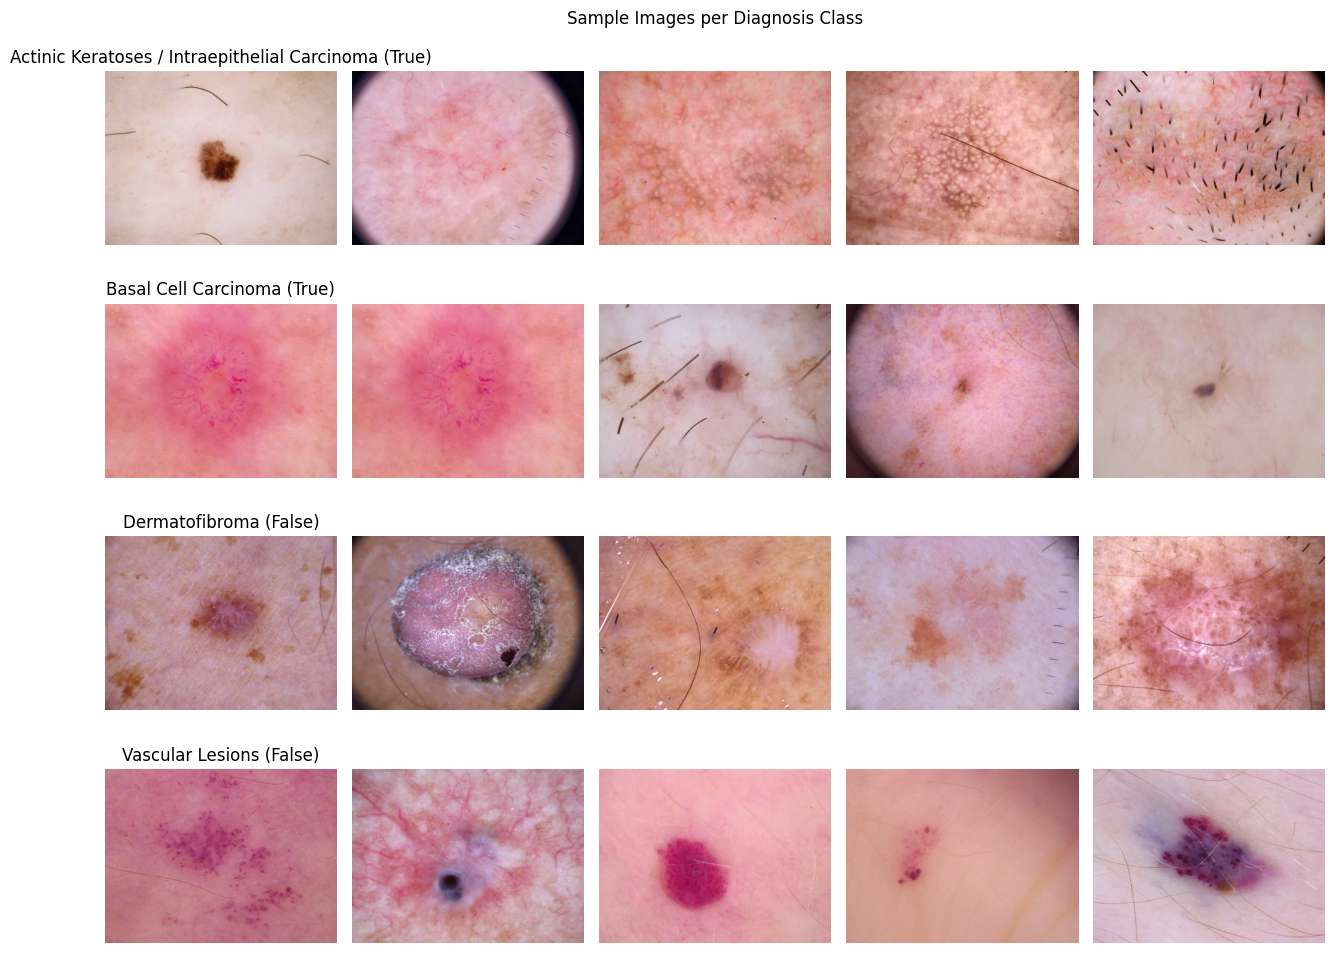

In [9]:
classes = sorted(train_synthetic_df['dx'].unique())
n_classes = len(classes)
fig, axes = plt.subplots(n_classes, 5,
    figsize=(5 * 2.5, n_classes * 2.5))

for row_idx, dx in enumerate(classes):
    subset = train_synthetic_df[train_synthetic_df['dx'] == dx]
    samples = subset.sample(min(5, len(subset)))

    for col_idx in range(5):
        ax = axes[row_idx][col_idx]
        img = Image.open(samples.iloc[col_idx]['image_path'])
        ax.imshow(img)

        ax.axis('off')
        if col_idx == 0:
            m = samples.iloc[col_idx]['malignant']
            ax.set_title(f'{LABEL_MAP[dx]} ({m})')

plt.suptitle('Sample Images per Diagnosis Class')
plt.tight_layout()
plt.show()

In [10]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
checkpoint_cb = callbacks.ModelCheckpoint(
    "skin_cancer_resnet50_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop_cb = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callback_list = [checkpoint_cb, earlystop_cb, reduce_lr_cb]

In [12]:
EPOCHS_STAGE_1 = 10

history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_1,
    callbacks=callback_list,
    verbose=1
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3822 - loss: 1.8730
Epoch 1: val_accuracy improved from None to 0.64980, saving model to skin_cancer_resnet50_best.keras

Epoch 1: finished saving model to skin_cancer_resnet50_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.4651 - loss: 1.5127 - val_accuracy: 0.6498 - val_loss: 0.9901 - learning_rate: 0.0010
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5803 - loss: 1.1113
Epoch 2: val_accuracy improved from 0.64980 to 0.69041, saving model to skin_cancer_resnet50_best.keras

Epoch 2: finished saving model to skin_cancer_resnet50_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.5989 - loss: 1.0636 - val_accuracy: 0.6904 - val_loss: 0.8166 - learning_rate: 0.0010
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6493 - loss: 0.9407
Epoch 3: val_accuracy did not improve from 0.69041
110/110 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.6377 - loss: 0.

In [13]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_STAGE_2 = 10
total_epochs = EPOCHS_STAGE_1 + EPOCHS_STAGE_2

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history_1.epoch[-1] + 1,
    epochs=total_epochs,
    callbacks=callback_list,
    verbose=1
)

Epoch 9/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5817 - loss: 1.1897
Epoch 9: val_accuracy did not improve from 0.70439
110/110 ━━━━━━━━━━━━━━━━━━━━ 340s 3s/step - accuracy: 0.6071 - loss: 1.0790 - val_accuracy: 0.6598 - val_loss: 0.8539 - learning_rate: 1.0000e-05
Epoch 10/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6846 - loss: 0.8201
Epoch 10: val_accuracy did not improve from 0.70439

Epoch 10: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
110/110 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - accuracy: 0.6991 - loss: 0.7986 - val_accuracy: 0.7044 - val_loss: 0.7504 - learning_rate: 1.0000e-05
Epoch 11/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7122 - loss: 0.7511
Epoch 11: val_accuracy improved from 0.70439 to 0.71238, saving model to skin_cancer_resnet50_best.keras

Epoch 11: finished saving model to skin_cancer_resnet50_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.7286 - loss: 0.7147 - val_accuracy: 0.71

In [14]:
model.save("skin_cancer_resnet50.keras")
print("Final model saved as skin_cancer_resnet50.keras")

Final model saved as skin_cancer_resnet50.keras


In [15]:
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]
loss = history_1.history["loss"] + history_2.history["loss"]
val_loss = history_1.history["val_loss"] + history_2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

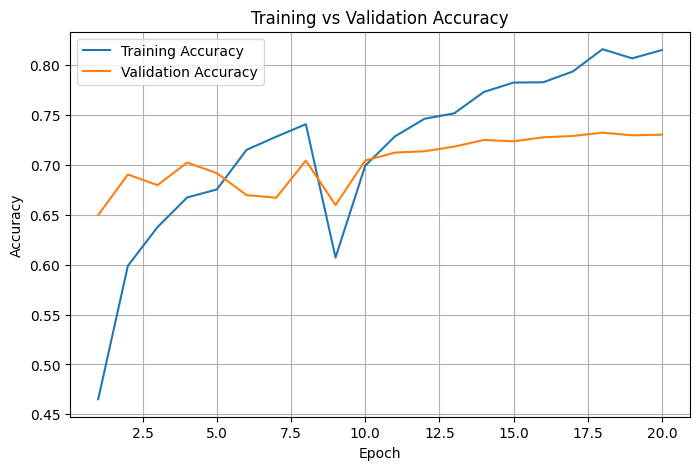

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

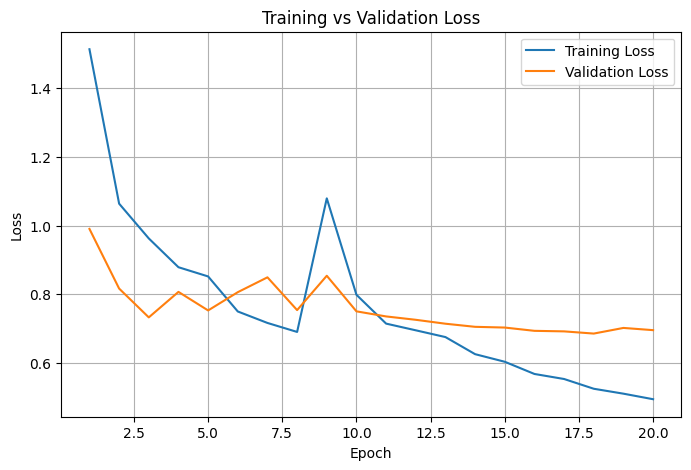

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6946 - loss: 0.7765
Test Loss: 0.7765
Test Accuracy: 0.6946


In [19]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [20]:
report = classification_report(
    y_true,
    y_pred,
    target_names=[LABEL_MAP[c] for c in CLASS_NAMES],
    digits=4
)
print(report)

                                               precision    recall  f1-score   support

Actinic Keratoses / Intraepithelial Carcinoma     0.5556    0.5102    0.5319        49
                         Basal Cell Carcinoma     0.4370    0.6753    0.5306        77
                             Benign Keratosis     0.4286    0.6182    0.5062       165
                               Dermatofibroma     0.4000    0.4706    0.4324        17
                                     Melanoma     0.3732    0.6347    0.4701       167
                             Melanocytic Nevi     0.9546    0.7316    0.8284      1006
                             Vascular Lesions     0.5769    0.6818    0.6250        22

                                     accuracy                         0.6946      1503
                                    macro avg     0.5323    0.6175    0.5607      1503
                                 weighted avg     0.7809    0.6946    0.7208      1503



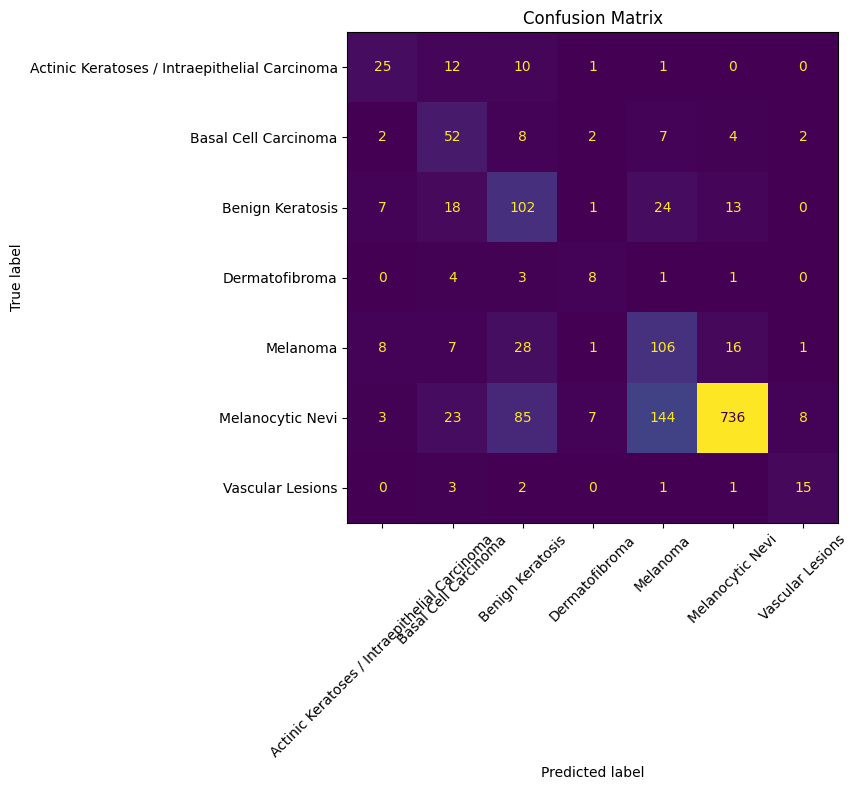

In [21]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[LABEL_MAP[c] for c in CLASS_NAMES]
)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
malignant_classes = {"mel", "bcc", "akiec"}

y_true_binary = np.array([
    1 if CLASS_NAMES[idx] in malignant_classes else 0
    for idx in y_true
])

y_pred_binary = np.array([
    1 if CLASS_NAMES[idx] in malignant_classes else 0
    for idx in y_pred
])

print("Malignant vs Benign Report:")
print(classification_report(
    y_true_binary,
    y_pred_binary,
    target_names=["Benign", "Malignant"],
    digits=4
))

Malignant vs Benign Report:
              precision    recall  f1-score   support

      Benign     0.9308    0.8116    0.8671      1210
   Malignant     0.4911    0.7509    0.5938       293

    accuracy                         0.7997      1503
   macro avg     0.7109    0.7812    0.7305      1503
weighted avg     0.8451    0.7997    0.8138      1503

